In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_excel("flight_components_condition_expanded (1).xlsx")

In [ ]:
print(df.head())

print(df.info())

   Component ID  Component Type  Model  Serial Number  Manufacturer  \
0             0               0      2           1652             3   
1             1               6      4           1137             3   
2             2               3     10           2061             0   
3             3               3      5           2053             6   
4             4               0      2            177             1   

   Aircraft ID  Install Date  Flight Hours  Cycles  Wear Level (%)  \
0            0           671        6912.0    4638            52.7   
1            8           386        5550.0    2822            50.2   
2            5           551        6649.8    5292             7.8   
3            3           700        7270.2    5576            14.7   
4            9           577        4319.9    2011            39.6   

   Condition Status  Last Inspection Date  Next Inspection Due  \
0                 0                   689                  848   
1                 0 

In [ ]:
df = df.dropna()

In [ ]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col].astype(str))

In [ ]:
X = df.drop("Condition Status", axis=1)

y = df["Condition Status"]

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svm_model.fit(X_train, y_train)

SVC()

In [89]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.954


In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       128
           1       0.98      0.99      0.98       354
           2       0.00      0.00      0.00         4
           3       0.78      0.50      0.61        14

    accuracy                           0.95       500
   macro avg       0.66      0.61      0.63       500
weighted avg       0.94      0.95      0.95       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [91]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[120   8   0   0]
 [  4 350   0   0]
 [  2   0   0   2]
 [  7   0   0   7]]


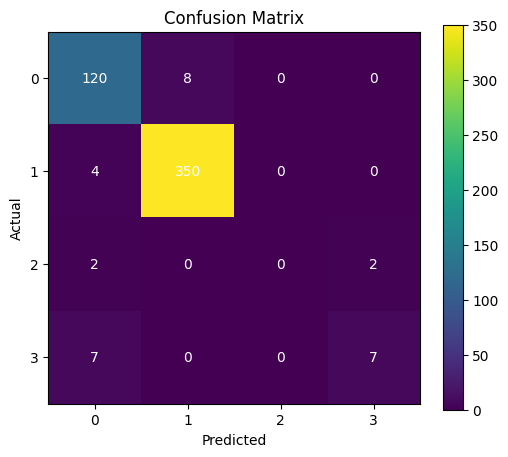

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(range(len(np.unique(y))), np.unique(y))
plt.yticks(range(len(np.unique(y))), np.unique(y))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 color='white')

plt.show()

In [93]:
sample = X_test[0].reshape(1, -1)

prediction = svm_model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]


In [94]:
target_encoder = LabelEncoder()

df["Condition Status"] = target_encoder.fit_transform(df["Condition Status"])

In [95]:
pred = svm_model.predict(sample)

print(target_encoder.inverse_transform(pred))

[1]
